# Titanic Survival Prediction — Data Cleaning & Feature Engineering

In this notebook we clean the raw dataset and engineer features that will improve model performance.

**What you'll learn:**
- Handling missing values with different strategies
- Encoding categorical variables
- Feature engineering (creating new meaningful features)
- Preparing data for machine learning

## 1. Import Libraries and Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

df = pd.read_csv("data/titanic.csv")
print(f"Original shape: {df.shape}")
df.head()


Original shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Total missing: 866


## 2. Handle Missing Values

### 2.1 Cabin — Drop it
Cabin has ~77% missing values. We can't reliably impute this, so we'll drop it. However, let's first check if *having* a cabin number is predictive.

In [ ]:
# Check if having a cabin recorded affects survival
df["HasCabin"] = df["Cabin"].notna().astype(int)

print("Survival rate by HasCabin:")
print(df.groupby("HasCabin")["Survived"].mean())
print("\nPassengers with a cabin number had a much higher survival rate!")
print("We'll keep HasCabin as a feature and drop the raw Cabin column.")


Survival rate by HasCabin:
HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64

Passengers with a cabin number had a much higher survival rate!
We'll keep HasCabin as a feature and drop the raw Cabin column.


In [ ]:
# Drop the raw Cabin column
df = df.drop(columns=["Cabin"])


### 2.2 Age — Impute with Group Median

Instead of filling Age with the overall median (which ignores context), we'll fill it using the **median age per (Pclass, Sex)** group. This is more accurate because age distributions differ by class and sex.

In [ ]:
# Show median age by Pclass and Sex
print("Median age by Pclass and Sex:")
print(df.groupby(["Pclass", "Sex"])["Age"].median())
print(f"\nMissing Age values before imputation: {df['Age'].isnull().sum()}")


Median age by Pclass and Sex:
Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

Missing Age values before imputation: 177


In [ ]:
# Fill missing Age with group median
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)

# Fill any remaining NaN (edge cases) with overall median
df["Age"] = df["Age"].fillna(df["Age"].median())

print(f"Missing Age values after imputation: {df['Age'].isnull().sum()}")


Missing Age values after imputation: 0


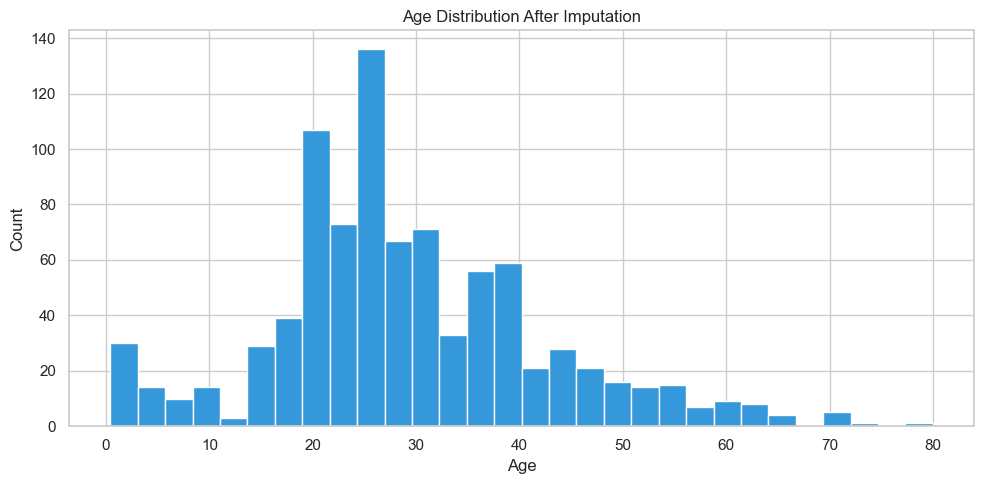

In [ ]:
# Visualize Age distribution after imputation
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["Age"], bins=30, color="#3498db", edgecolor="white")
ax.set_title("Age Distribution After Imputation")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


### 2.3 Embarked — Fill with Mode

In [ ]:
print(f"Missing Embarked values: {df['Embarked'].isnull().sum()}")
print(f"Mode of Embarked: {df['Embarked'].mode()[0]}")

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print(f"Missing Embarked after filling: {df['Embarked'].isnull().sum()}")


Missing Embarked values: 2
Mode of Embarked: S
Missing Embarked after filling: 0


In [ ]:
# Confirm no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64

Total missing: 0


## 3. Feature Engineering

Let's create new features that capture patterns we discovered during EDA.

### 3.1 Title — Extract from Name

In [ ]:
# Extract title from Name
df["Title"] = df["Name"].apply(lambda x: x.split(",")[1].split(".")[0].strip())

print("Title counts:")
print(df["Title"].value_counts())


Title counts:
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64


In [ ]:
# Group rare titles together
title_mapping = {
    "Mr": "Mr",
    "Miss": "Miss",
    "Mrs": "Mrs",
    "Master": "Master",
}

df["Title"] = df["Title"].apply(lambda x: title_mapping.get(x, "Rare"))

print("\nTitle counts after grouping:")
print(df["Title"].value_counts())
print("\nSurvival rate by Title:")
print(df.groupby("Title")["Survived"].mean().sort_values(ascending=False))



Title counts after grouping:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

Survival rate by Title:
Title
Mrs       0.792000
Miss      0.697802
Master    0.575000
Rare      0.444444
Mr        0.156673
Name: Survived, dtype: float64


### 3.2 Family Size and IsAlone

In [ ]:
# Family size
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Is alone flag
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

print(f"Solo travelers: {df['IsAlone'].sum()} ({df['IsAlone'].mean():.1%})")
print(f"\nSurvival rate — Alone: {df[df['IsAlone']==1]['Survived'].mean():.2%}")
print(f"Survival rate — With Family: {df[df['IsAlone']==0]['Survived'].mean():.2%}")


Solo travelers: 537 (60.3%)

Survival rate — Alone: 30.35%
Survival rate — With Family: 50.56%


### 3.3 Age Groups

In [ ]:
# Bin ages into groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 80],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

print("Age group distribution:")
print(df["AgeGroup"].value_counts().sort_index())
print("\nSurvival rate by Age Group:")
print(df.groupby("AgeGroup")["Survived"].mean())


Age group distribution:
AgeGroup
Child           69
Teen            70
Young Adult    514
Adult          216
Senior          22
Name: count, dtype: int64

Survival rate by Age Group:
AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.357977
Adult          0.384259
Senior         0.227273
Name: Survived, dtype: float64


/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_9244/838579762.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("AgeGroup")["Survived"].mean())


### 3.4 Fare Bins

In [ ]:
# Bin fare into quartiles
df["FareBin"] = pd.qcut(
    df["Fare"], q=4, labels=["Low", "Medium", "High", "Very High"]
)

print("Survival rate by Fare Bin:")
print(df.groupby("FareBin")["Survived"].mean())


Survival rate by Fare Bin:
FareBin
Low          0.197309
Medium       0.303571
High         0.454955
Very High    0.581081
Name: Survived, dtype: float64


/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_9244/28673781.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("FareBin")["Survived"].mean())


## 4. Encode Categorical Variables

In [ ]:
# View current dtypes
print("Current columns and types:")
print(df.dtypes)
print(f"\nShape: {df.shape}")


Current columns and types:
PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked         object
HasCabin          int64
Title            object
FamilySize        int64
IsAlone           int64
AgeGroup       category
FareBin        category
dtype: object

Shape: (891, 17)


In [ ]:
# Encode Sex
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# One-hot encode Embarked, Title, AgeGroup, FareBin
df = pd.get_dummies(df, columns=["Embarked", "Title", "AgeGroup", "FareBin"], drop_first=True, dtype=int)

print(f"Shape after encoding: {df.shape}")
df.head()


Shape after encoding: (891, 26)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior,FareBin_Medium,FareBin_High,FareBin_Very High
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,...,1,0,0,0,1,0,0,0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,...,0,1,0,0,0,1,0,0,0,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,...,0,0,0,0,1,0,0,1,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,...,0,1,0,0,1,0,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,...,1,0,0,0,1,0,0,1,0,0


## 5. Drop Unnecessary Columns

In [ ]:
# Drop columns not useful for modeling
drop_cols = ["PassengerId", "Name", "Ticket"]
df = df.drop(columns=drop_cols)

print(f"Final shape: {df.shape}")
print(f"\nFinal columns:")
print(df.columns.tolist())


Final shape: (891, 23)

Final columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Teen', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'FareBin_Medium', 'FareBin_High', 'FareBin_Very High']


In [ ]:
# Final check
print("Missing values:")
print(df.isnull().sum().sum())
print("\nData types:")
print(df.dtypes)


Missing values:
0

Data types:
Survived                  int64
Pclass                    int64
Sex                       int64
Age                     float64
SibSp                     int64
Parch                     int64
Fare                    float64
HasCabin                  int64
FamilySize                int64
IsAlone                   int64
Embarked_Q                int64
Embarked_S                int64
Title_Miss                int64
Title_Mr                  int64
Title_Mrs                 int64
Title_Rare                int64
AgeGroup_Teen             int64
AgeGroup_Young Adult      int64
AgeGroup_Adult            int64
AgeGroup_Senior           int64
FareBin_Medium            int64
FareBin_High              int64
FareBin_Very High         int64
dtype: object


## 6. Save Cleaned Data

In [ ]:
# Save the cleaned and engineered dataset
df.to_csv("data/titanic_cleaned.csv", index=False)
print("Cleaned dataset saved to data/titanic_cleaned.csv")
print(f"Final shape: {df.shape}")
df.head()


Cleaned dataset saved to data/titanic_cleaned.csv
Final shape: (891, 23)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,...,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior,FareBin_Medium,FareBin_High,FareBin_Very High
0,0,3,0,22.0,1,0,7.2500,0,2,0,...,1,0,0,0,1,0,0,0,0,0
1,1,1,1,38.0,1,0,71.2833,1,2,0,...,0,1,0,0,0,1,0,0,0,1
2,1,3,1,26.0,0,0,7.9250,0,1,1,...,0,0,0,0,1,0,0,1,0,0
3,1,1,1,35.0,1,0,53.1000,1,2,0,...,0,1,0,0,1,0,0,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,1,1,...,1,0,0,0,1,0,0,1,0,0


## 7. Summary

| Step | Action |
|------|--------|
| Cabin | Created `HasCabin` flag, then dropped raw column |
| Age | Imputed missing values using group median (Pclass, Sex) |
| Embarked | Filled 2 missing values with mode (S) |
| Title | Extracted from Name, grouped rare titles |
| FamilySize | Created from SibSp + Parch + 1 |
| IsAlone | Binary flag for solo travelers |
| AgeGroup | Binned Age into 5 categories |
| FareBin | Binned Fare into quartiles |
| Encoding | Label encoded Sex, one-hot encoded categoricals |
| Dropped | PassengerId, Name, Ticket (not useful for modeling) |

The cleaned dataset is ready for model training in the next notebook.